# Pneumonia Detection using DenseNet121
## Binary Classification with Deep Learning

This notebook demonstrates building a medical image classification model to detect pneumonia in chest X-rays. We start with a baseline transfer learning approach using DenseNet121, then progressively improve the model using advanced techniques including:
- Class weighting for imbalanced datasets
- Fine-tuning pretrained layers
- Dropout regularization
- Learning rate scheduling

**Dataset**: Chest X-ray images labeled as either NORMAL or PNEUMONIA (binary classification)

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import kagglehub
import os
import time
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from sklearn.metrics import accuracy_score
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() 
                      else "mps" if torch.mps.is_available() 
                      else "cpu")

print(f'Current device: {device}')

Current device: cuda


In [3]:
np.random.seed(1)
torch.manual_seed(1)

In [4]:
class PneumoniaDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        for label in ['NORMAL', 'PNEUMONIA']:
            class_dir = os.path.join(root_dir, label)
            for img_name in os.listdir(class_dir):
                self.image_paths.append(os.path.join(class_dir, img_name))
                self.labels.append(0 if label == 'NORMAL' else 1)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB')

        if self.transform:
            image = self.transform(image)
            
        return image, self.labels[idx]

In [5]:
# https://pytorch.org/hub/pytorch_vision_densenet/
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

## Data Augmentation & Preprocessing

**Training transforms** apply random augmentations to increase dataset diversity:
- `RandomHorizontalFlip`: Pneumonia symptoms are typically symmetric
- `RandomRotation`: Images may be taken at slight angles
- `ColorJitter`: Accounts for variations in imaging equipment and lighting
- `Normalize`: Using ImageNet statistics aligns with DenseNet's pretraining

**Validation/Test transforms** apply only deterministic resizing and normalization—no augmentation, for fair evaluation.


In [6]:
train_dataset = PneumoniaDataset(root_dir='/kaggle/input/chest-xray-pneumonia/chest_xray/train', transform=train_transform)
valid_dataset = PneumoniaDataset(root_dir='/kaggle/input/chest-xray-pneumonia/chest_xray/val', transform=transform)
test_dataset = PneumoniaDataset(root_dir='/kaggle/input/chest-xray-pneumonia/chest_xray/test', transform=transform)

In [7]:
counts = Counter(train_dataset.labels)

print('NORMAL:', counts[0])
print('PNEUMONIA:', counts[1])

NORMAL: 1341
PNEUMONIA: 3875


## Data Exploration

Check class distribution—imbalanced datasets are common in medical imaging where healthy cases often outnumber disease cases.


In [8]:
print('Train: ', len(train_dataset))
print('Valid: ', len(valid_dataset))
print('Test:  ', len(test_dataset))

Train:  5216
Valid:  16
Test:   624


In [9]:
batch_size = 64

train_dl = DataLoader(train_dataset, batch_size, shuffle=True)
valid_dl = DataLoader(valid_dataset, batch_size, shuffle=True)
test_dl = DataLoader(test_dataset, batch_size, shuffle=False)

In [10]:
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
model

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 150MB/s]


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

## Baseline Model: Transfer Learning Approach

**Strategy**: Load a pretrained DenseNet121 model (trained on ImageNet) and adapt it for pneumonia detection:
1. **Freeze** all convolutional layers to preserve learned features from ImageNet
2. **Replace** the final classification head to output 2 classes (NORMAL/PNEUMONIA)
3. **Train only** the new classification layer with a modest learning rate


In [11]:
for param in model.parameters():
    param.requires_grad = False
    
model.classifier = nn.Linear(model.classifier.in_features, 2)

for param in model.classifier.parameters():
    param.requires_grad = True

model.to(device)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [12]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), 
    lr=1e-3,
    weight_decay=1e-5
)

In [13]:
def train(model, train_dl, valid_dl, loss_fn, optimizer, scheduler=None, early_stopping=False, num_epochs=10):
    training_loss = []
    valid_loss = []

    patience = 7
    best_eval_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        model.train()
        epoch_training_loss, epoch_valid_loss = 0, 0
        valid_predictions, valid_labels = [], []
    
        for batch in train_dl:
            optimizer.zero_grad()
            
            inputs, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            output = model(inputs)
            loss = loss_fn(output, labels)
            loss.backward()
            optimizer.step()
            epoch_training_loss += loss.item() * inputs.size(0)
    
        model.eval()
        with torch.no_grad():
            for batch in valid_dl:
                inputs, labels = batch
                inputs = inputs.to(device)
                labels = labels.to(device)
    
                output = model(inputs)
                loss = loss_fn(output, labels)
                epoch_valid_loss += loss.item() * inputs.size(0)
    
                predictions = output.argmax(dim=1)
                valid_predictions.extend(predictions.cpu().numpy())
                valid_labels.extend(labels.cpu().numpy())
    
        epoch_training_loss /= len(train_dl.dataset)
        epoch_valid_loss /= len(valid_dl.dataset)
    
        accuracy = accuracy_score(valid_labels, valid_predictions)

        if scheduler:
            if isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
                scheduler.step()
            else:
                scheduler.step(epoch_valid_loss)
    
        print(f'Epoch {epoch+1}/{num_epochs} Train loss -> {epoch_training_loss:.4f} '
              f'Valid loss -> {epoch_valid_loss:.4f}. '
              f'Valid acc -> {accuracy*100:.2f}% '
              f'Epoch time: {(time.time()-epoch_start_time)/60:.2f} min')
        
        training_loss.append(epoch_training_loss)
        valid_loss.append(epoch_valid_loss)

        if early_stopping:
            if epoch_valid_loss < best_eval_loss:
                best_eval_loss = epoch_valid_loss
                patience_counter = 0
                torch.save(model.state_dict(), 'x_ray_best_model.pth')
            else:
                patience_counter += 1

            if patience_counter > patience:
                break
            print()

    if early_stopping and os.path.exists('x_ray_best_model.pth'):
        model.load_state_dict(torch.load('x_ray_best_model.pth'))
    return model, training_loss, valid_loss

In [14]:
def plot_training_loss(training_loss, validation_loss):
    x_range = np.arange(len(training_loss))

    plt.figure()
    plt.plot(x_range, training_loss, label='Training loss')
    plt.plot(x_range, validation_loss, label='Validation loss')
    plt.xlabel('Epochs', size=15)
    plt.ylabel('Loss', size=15)
    plt.legend()
    plt.show()

In [15]:
def calculate_test_accuracy(model, test_dl, threshold=0.5):
    model.eval()
    test_preds = []
    test_labels = []
    
    with torch.no_grad():
        for batch in test_dl:
            inputs, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            predictions = (probs > threshold).long()
    
            test_preds.extend(predictions.cpu().numpy())
            test_labels.extend(labels.cpu().numpy())
    
    test_accuracy = accuracy_score(test_labels, test_preds)
    print(f'Test accuracy: {test_accuracy*100:.2f}%')

    return test_labels, test_preds

In [16]:
model, training_loss, validation_loss = train(model, train_dl, valid_dl, loss_fn, optimizer)

Epoch 1/10 Train loss -> 0.3489 Valid loss -> 0.3915. Valid acc -> 81.25% Epoch time: 2.31 min
Epoch 2/10 Train loss -> 0.1990 Valid loss -> 0.3864. Valid acc -> 81.25% Epoch time: 1.79 min
Epoch 3/10 Train loss -> 0.1615 Valid loss -> 0.3390. Valid acc -> 81.25% Epoch time: 1.80 min
Epoch 4/10 Train loss -> 0.1539 Valid loss -> 0.3123. Valid acc -> 81.25% Epoch time: 1.91 min
Epoch 5/10 Train loss -> 0.1484 Valid loss -> 0.4176. Valid acc -> 75.00% Epoch time: 1.97 min
Epoch 6/10 Train loss -> 0.1460 Valid loss -> 0.3770. Valid acc -> 75.00% Epoch time: 1.87 min
Epoch 7/10 Train loss -> 0.1343 Valid loss -> 0.3020. Valid acc -> 81.25% Epoch time: 1.82 min
Epoch 8/10 Train loss -> 0.1277 Valid loss -> 0.2671. Valid acc -> 81.25% Epoch time: 1.80 min
Epoch 9/10 Train loss -> 0.1254 Valid loss -> 0.3395. Valid acc -> 75.00% Epoch time: 1.80 min
Epoch 10/10 Train loss -> 0.1226 Valid loss -> 0.2955. Valid acc -> 81.25% Epoch time: 1.79 min


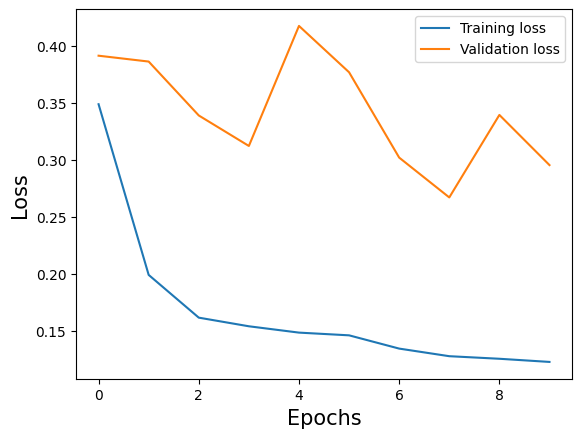

In [17]:
plot_training_loss(training_loss, validation_loss)

In [18]:
test_labels, test_preds = calculate_test_accuracy(model, test_dl)

Test accuracy: 87.66%


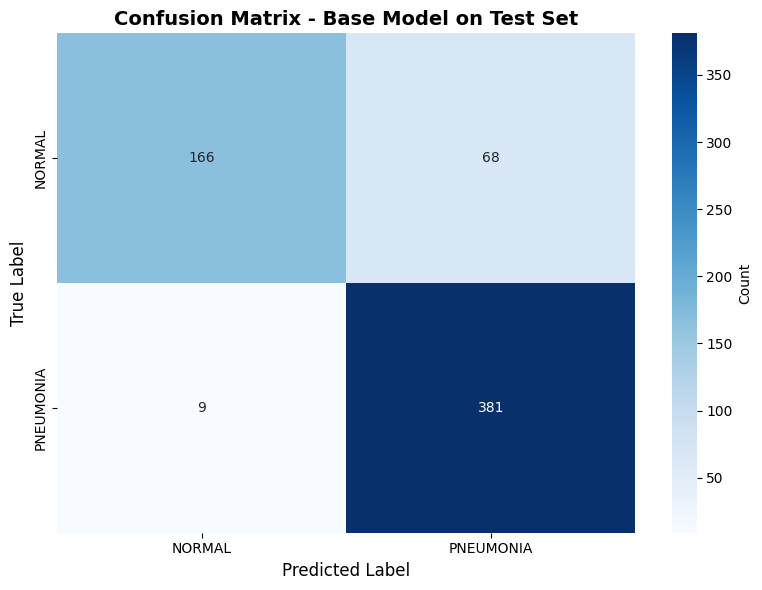


CLASSIFICATION REPORT - BASE MODEL
              precision    recall  f1-score   support

      NORMAL       0.95      0.71      0.81       234
   PNEUMONIA       0.85      0.98      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.84      0.86       624
weighted avg       0.89      0.88      0.87       624



In [19]:
cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            cbar_kws={'label': 'Count'},
            ax=ax)
ax.set_ylabel('True Label', size=12)
ax.set_xlabel('Predicted Label', size=12)
ax.set_title('Confusion Matrix - Base Model on Test Set', size=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n' + '='*50)
print('CLASSIFICATION REPORT - BASE MODEL')
print('='*50)
print(classification_report(test_labels, test_preds, 
                          target_names=['NORMAL', 'PNEUMONIA']))

In [20]:

baseline_test_labels = test_labels
baseline_test_preds = test_preds
baseline_accuracy = accuracy_score(baseline_test_labels, baseline_test_preds)

print(f"\nBaseline Model Accuracy (threshold=0.5): {baseline_accuracy*100:.2f}%")



Baseline Model Accuracy (threshold=0.5): 87.66%


### Baseline Model Results

The baseline model achieves decent performance with simple transfer learning:
- Freezes all layers except the final classification head
- Uses standard cross-entropy loss
- Minimal fine-tuning

However, there are opportunities for improvement

## Aggressive Fine-tuning

This section will aim to improve over the base model by making some adjustment including:

- Resample the data
- Add weights to the classes
- Use a more aggressive transformation for training
- Unfreeze the last dense block AND normalization layer
- Use modest learning rates with minimal regularization (wd=1e-5)
- Train for larger number of epochs

In [21]:
train_dataset = PneumoniaDataset(root_dir='/kaggle/input/chest-xray-pneumonia/chest_xray/train', transform=transform)
valid_dataset = PneumoniaDataset(root_dir='/kaggle/input/chest-xray-pneumonia/chest_xray/val', transform=transform)

In [22]:
enhanced_train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

In [23]:
all_images = train_dataset.image_paths + valid_dataset.image_paths
all_labels = train_dataset.labels + valid_dataset.labels

In [24]:
indices = list(range(len(all_labels)))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.15,
    stratify=all_labels
)

In [25]:
full_dataset = PneumoniaDataset(root_dir='/kaggle/input/chest-xray-pneumonia/chest_xray/train', transform=transform)

full_dataset.image_paths = all_images
full_dataset.labels = all_labels

train_dataset = Subset(full_dataset, train_idx)
valid_dataset = Subset(full_dataset, val_idx)

train_dataset.dataset.transform = enhanced_train_transform

print('Size of train dataset', len(train_dataset))
print('Size of valid dataset', len(valid_dataset))

Size of train dataset 4447
Size of valid dataset 785


In [26]:
train_dl = DataLoader(train_dataset, batch_size, shuffle=True)
valid_dl = DataLoader(valid_dataset, batch_size, shuffle=True)

In [27]:
counts = Counter(train_dataset.dataset.labels)

normal_count, positive_count = counts[0], counts[1]

print('NORMAL:', normal_count)
print('PNEUMONIA:', positive_count)

NORMAL: 1349
PNEUMONIA: 3883


## Handling Class Imbalance

**Weighted Cross-Entropy Loss** assigns higher penalty to misclassifying the minority class (PNEUMONIA). This prevents the model from achieving high accuracy by simply predicting "NORMAL" for everything. The weights are inversely proportional to class frequency.


In [28]:
total = normal_count + positive_count
weight_normal = total / (2*normal_count)
weight_positive = total / (2*positive_count)

weights = torch.tensor([weight_normal, weight_positive]).to(device)

In [29]:
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

In [30]:
for param in model.parameters():
    param.requires_grad = False
    
model.classifier = nn.Sequential(
    nn.Linear(model.classifier.in_features, 2)
)

for param in model.classifier.parameters():
    param.requires_grad = True

model.to(device)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [31]:
loss_fn = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-4,
    weight_decay=1e-4
)

In [32]:
model, training_loss, validation_loss = train(
    model, train_dl, valid_dl, loss_fn, optimizer, scheduler=None, early_stopping=False, num_epochs=20
)

Epoch 1/20 Train loss -> 0.5042 Valid loss -> 0.3484. Valid acc -> 92.23% Epoch time: 1.72 min
Epoch 2/20 Train loss -> 0.3015 Valid loss -> 0.2507. Valid acc -> 93.12% Epoch time: 1.73 min
Epoch 3/20 Train loss -> 0.2422 Valid loss -> 0.2278. Valid acc -> 90.57% Epoch time: 1.75 min
Epoch 4/20 Train loss -> 0.2240 Valid loss -> 0.2017. Valid acc -> 92.99% Epoch time: 1.76 min
Epoch 5/20 Train loss -> 0.2062 Valid loss -> 0.1637. Valid acc -> 95.03% Epoch time: 1.73 min
Epoch 6/20 Train loss -> 0.1851 Valid loss -> 0.1585. Valid acc -> 94.39% Epoch time: 1.74 min
Epoch 7/20 Train loss -> 0.1905 Valid loss -> 0.1690. Valid acc -> 93.76% Epoch time: 1.71 min
Epoch 8/20 Train loss -> 0.1762 Valid loss -> 0.1470. Valid acc -> 94.78% Epoch time: 1.69 min
Epoch 9/20 Train loss -> 0.1721 Valid loss -> 0.1460. Valid acc -> 93.76% Epoch time: 1.69 min
Epoch 10/20 Train loss -> 0.1595 Valid loss -> 0.1495. Valid acc -> 95.54% Epoch time: 1.71 min
Epoch 11/20 Train loss -> 0.1582 Valid loss -> 0.

In [33]:
for param in model.features.denseblock4.parameters():
    param.requires_grad = True

for param in model.features.norm5.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(
    [
        {"params": model.features.denseblock4.parameters(), "lr": 1e-5},
        {"params": model.features.norm5.parameters(), "lr": 5e-5},
        {"params": model.classifier.parameters(), "lr": 5e-4},
    ], 
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
)

In [34]:
model, training_loss, validation_loss = train(
    model, train_dl, valid_dl, loss_fn, optimizer, scheduler=scheduler, early_stopping=True, num_epochs=25
)

Epoch 1/25 Train loss -> 0.1433 Valid loss -> 0.1156. Valid acc -> 96.31% Epoch time: 1.72 min

Epoch 2/25 Train loss -> 0.1200 Valid loss -> 0.0874. Valid acc -> 96.69% Epoch time: 1.72 min

Epoch 3/25 Train loss -> 0.1204 Valid loss -> 0.0952. Valid acc -> 96.43% Epoch time: 1.72 min

Epoch 4/25 Train loss -> 0.1079 Valid loss -> 0.0894. Valid acc -> 97.20% Epoch time: 1.71 min

Epoch 5/25 Train loss -> 0.0927 Valid loss -> 0.0904. Valid acc -> 97.32% Epoch time: 1.72 min

Epoch 6/25 Train loss -> 0.0986 Valid loss -> 0.0838. Valid acc -> 97.32% Epoch time: 1.71 min

Epoch 7/25 Train loss -> 0.0925 Valid loss -> 0.0742. Valid acc -> 96.69% Epoch time: 1.73 min

Epoch 8/25 Train loss -> 0.0880 Valid loss -> 0.0620. Valid acc -> 97.83% Epoch time: 1.73 min

Epoch 9/25 Train loss -> 0.0935 Valid loss -> 0.0760. Valid acc -> 97.45% Epoch time: 2.00 min

Epoch 10/25 Train loss -> 0.0830 Valid loss -> 0.0792. Valid acc -> 97.07% Epoch time: 1.93 min

Epoch 11/25 Train loss -> 0.0841 Valid 

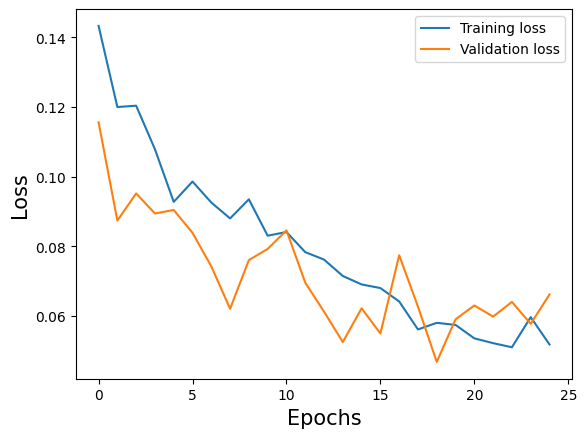

In [35]:
plot_training_loss(training_loss, validation_loss)

In [36]:
test_labels, test_preds = calculate_test_accuracy(model, test_dl, threshold=0.5)

Test accuracy: 76.76%


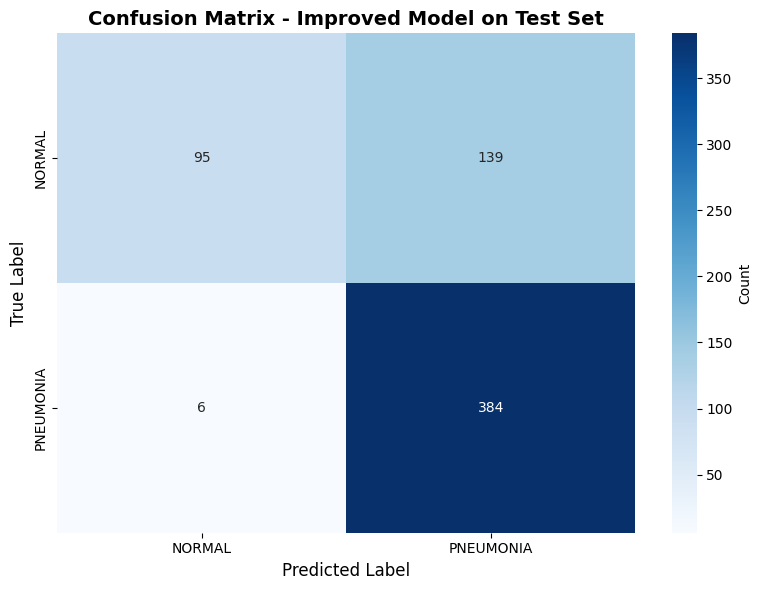


CLASSIFICATION REPORT - IMPROVED MODEL
              precision    recall  f1-score   support

      NORMAL       0.94      0.41      0.57       234
   PNEUMONIA       0.73      0.98      0.84       390

    accuracy                           0.77       624
   macro avg       0.84      0.70      0.70       624
weighted avg       0.81      0.77      0.74       624



In [37]:
cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            cbar_kws={'label': 'Count'},
            ax=ax)
ax.set_ylabel('True Label', size=12)
ax.set_xlabel('Predicted Label', size=12)
ax.set_title('Confusion Matrix - Improved Model on Test Set', size=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n' + '='*50)
print('CLASSIFICATION REPORT - IMPROVED MODEL')
print('='*50)
print(classification_report(test_labels, test_preds, 
                          target_names=['NORMAL', 'PNEUMONIA']))

In [38]:
finetuned_accuracy = accuracy_score(test_labels, test_preds)

print("\n" + "="*50)
print("SECTION 2 RESULTS: AGGRESSIVE FINE-TUNING")
print("="*50)
print(f"Baseline Model Accuracy:  {baseline_accuracy*100:.2f}%")
print(f"Aggressive FT Accuracy:   {finetuned_accuracy*100:.2f}%")
print(f"Difference:               {(finetuned_accuracy - baseline_accuracy)*100:+.2f}%")
print("="*50)


SECTION 2 RESULTS: AGGRESSIVE FINE-TUNING
Baseline Model Accuracy:  87.66%
Aggressive FT Accuracy:   76.76%
Difference:               -10.90%


## Balanced Finetuning

This section will aim to use some of the techniques used in section 2 while maintaining the idea of the first section.

- Use initial train and validation set
- Use original transformations
- ONLY unfreeze denseblock with a low learning rate


In [39]:

train_dataset = PneumoniaDataset(root_dir='/kaggle/input/chest-xray-pneumonia/chest_xray/train', transform=train_transform)
valid_dataset = PneumoniaDataset(root_dir='/kaggle/input/chest-xray-pneumonia/chest_xray/val', transform=transform)

train_dl = DataLoader(train_dataset, batch_size, shuffle=True)
valid_dl = DataLoader(valid_dataset, batch_size, shuffle=True)

print(f"Train Dataset Size: {len(train_dataset)}")
print(f"Valid Dataset Size: {len(valid_dataset)}")


Train Dataset Size: 5216
Valid Dataset Size: 16


In [40]:

model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

model.classifier = nn.Sequential(
    nn.Dropout(0.35),
    nn.Linear(model.classifier.in_features, 2)
)

for param in model.features.parameters():
    param.requires_grad = False

for param in model.features.denseblock4.parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

model.to(device)

optimizer = torch.optim.AdamW(
    [
        {"params": model.features.denseblock4.parameters(), "lr": 1e-6},
        {"params": model.classifier.parameters(), "lr": 5e-4},
    ], 
    weight_decay=2e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
)


In [41]:

model, training_loss, validation_loss = train(
    model, train_dl, valid_dl, loss_fn, optimizer, 
    scheduler=scheduler, early_stopping=False, num_epochs=30
)


Epoch 1/30 Train loss -> 0.4745 Valid loss -> 0.3900. Valid acc -> 81.25% Epoch time: 1.80 min
Epoch 2/30 Train loss -> 0.3019 Valid loss -> 0.3592. Valid acc -> 75.00% Epoch time: 1.79 min
Epoch 3/30 Train loss -> 0.2410 Valid loss -> 0.3088. Valid acc -> 81.25% Epoch time: 1.81 min
Epoch 4/30 Train loss -> 0.2282 Valid loss -> 0.2797. Valid acc -> 81.25% Epoch time: 1.81 min
Epoch 5/30 Train loss -> 0.2000 Valid loss -> 0.2782. Valid acc -> 93.75% Epoch time: 1.79 min
Epoch 6/30 Train loss -> 0.1975 Valid loss -> 0.2818. Valid acc -> 87.50% Epoch time: 1.82 min
Epoch 7/30 Train loss -> 0.1908 Valid loss -> 0.2783. Valid acc -> 87.50% Epoch time: 1.87 min
Epoch 8/30 Train loss -> 0.1818 Valid loss -> 0.2406. Valid acc -> 93.75% Epoch time: 1.82 min
Epoch 9/30 Train loss -> 0.1705 Valid loss -> 0.2356. Valid acc -> 93.75% Epoch time: 1.81 min
Epoch 10/30 Train loss -> 0.1697 Valid loss -> 0.2467. Valid acc -> 93.75% Epoch time: 1.82 min
Epoch 11/30 Train loss -> 0.1801 Valid loss -> 0.

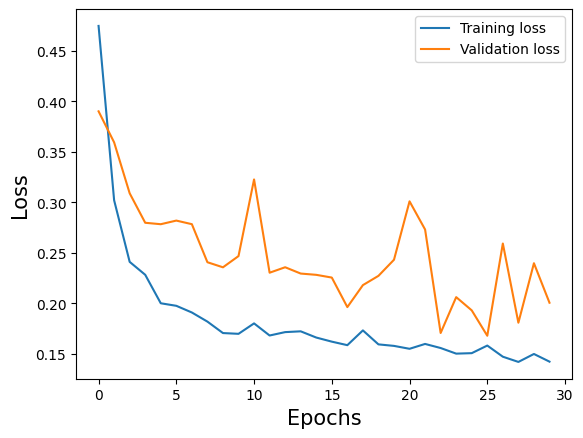

In [42]:

plot_training_loss(training_loss, validation_loss)


In [43]:

test_labels_finetuned, test_preds_finetuned = calculate_test_accuracy(model, test_dl)


Test accuracy: 89.58%


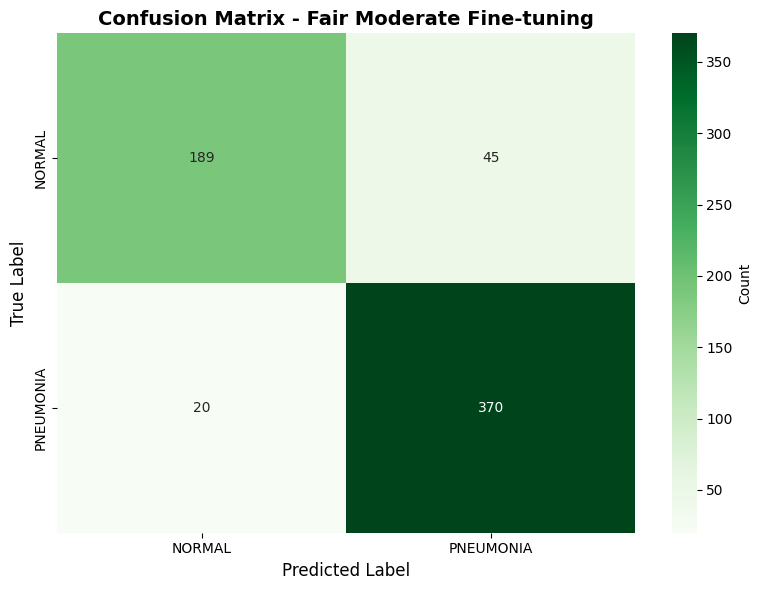


CLASSIFICATION REPORT - FAIR MODERATE
              precision    recall  f1-score   support

      NORMAL       0.90      0.81      0.85       234
   PNEUMONIA       0.89      0.95      0.92       390

    accuracy                           0.90       624
   macro avg       0.90      0.88      0.89       624
weighted avg       0.90      0.90      0.89       624



In [44]:
cm = confusion_matrix(test_labels_finetuned, test_preds_finetuned)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            cbar_kws={'label': 'Count'},
            ax=ax)
ax.set_ylabel('True Label', size=12)
ax.set_xlabel('Predicted Label', size=12)
ax.set_title('Confusion Matrix - Fair Moderate Fine-tuning', size=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n' + '='*50)
print('CLASSIFICATION REPORT - FAIR MODERATE')
print('='*50)
print(classification_report(test_labels_finetuned, test_preds_finetuned, 
                          target_names=['NORMAL', 'PNEUMONIA']))


In [45]:
finetuned_moderate_accuracy = accuracy_score(test_labels_finetuned, test_preds_finetuned)

print("\n" + "="*80)
print("FINAL COMPARISON: ALL APPROACHES")
print("="*80)
print(f"SECTION 1 - Minimum FT:                         {baseline_accuracy*100:.2f}%")
print(f"SECTION 2 - Aggressive FT + Resampled:          {finetuned_accuracy*100:.2f}%  (Δ {(finetuned_accuracy - baseline_accuracy)*100:+.2f}%)")
print(f"SECTION 3 - Moderate FT:                        {finetuned_moderate_accuracy*100:.2f}%  (Δ {(finetuned_moderate_accuracy - baseline_accuracy)*100:+.2f}%)")
print("="*80)

print("="*80)



FINAL COMPARISON: ALL APPROACHES
SECTION 1 - Minimum FT:                         87.66%
SECTION 2 - Aggressive FT + Resampled:          76.76%  (Δ -10.90%)
SECTION 3 - Moderate FT:                        89.58%  (Δ +1.92%)


## Conclusion

The balanced fine-tuning approach (Section 3) achieved better generalization compared to the baseline model. While recall worsen (more missed diagnoses), the accuracy increased. For medical applications, recall is particularly critical—minimizing false negatives (missed pneumonia cases) could be achieve by finding the best treshold for classifying a case as positive using the ROC curve analysis.

**Future improvements** ensemble methods, or exploring other architectures like ResNet or Vision Transformers could improve the current model. Additionally, other hyperparameters could improve the current architecture. Upon using different epochs, learning rates, training schedule, transformations, etc., the last section had gains over the best model, so a different combination of hyperparamters could generalize even better.
